# Calculating Indian Restaurant Density for Dutch Provinces

In [1]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import osmnx as ox

In [2]:
!ls ../../data

india_admin_areas.geojson   nederland_pop_centres.gpkg	 sources
nederland_admin_areas.gpkg  nederland_pop_stats.feather


## Inspecting the Provinces GeoPackage

In [3]:
data_folder = Path('../../data')
fiona.listlayers(f'{data_folder}/nederland_admin_areas.gpkg')

['cities', 'country', 'provinces']

In [4]:
provinces = gpd.read_file(f'{data_folder}/nederland_admin_areas.gpkg', layer='provinces')
provinces.shape

(12, 6)

In [5]:
provinces.head(1)

,identificatie,naam,code,ligt_in_land_code,ligt_in_land_naam,geometry
0,PV22,Drenthe,22,6030,Nederland,"MULTIPOLYGON (((231437.815 516445.643, 231430...."


## Visualising the Provinces

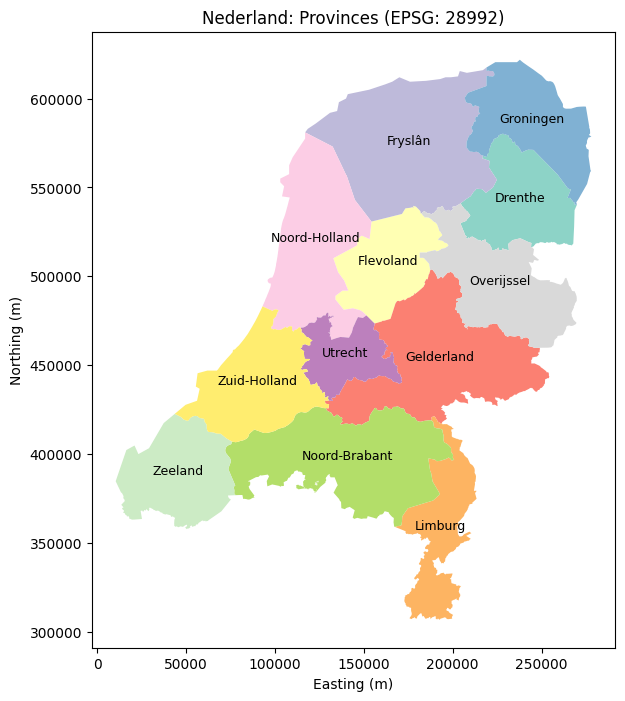

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
provinces.plot(ax=ax, cmap='Set3')

for row in provinces.itertuples():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(xy=(x,y), text=row.naam, ha='center', fontsize=9)

ax.set_title('Nederland: Provinces (EPSG: 28992)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

## Inspecting the Provincial Statistics DataFrame

In [7]:
stats = pd.read_feather(f'{data_folder}/nederland_pop_stats.feather')
stats.shape

(12, 14)

In [8]:
stats.head(1)

,region,total_population,population_density,total_births,birth_ratio,total_deaths,death_ratio,total_arrivals,arrival_ratio,total_departures,departure_ratio,net_migration,total_population_growth,population_growth_ratio
0,Groningen,601347,260.0,4816,8.0,6294,10.5,58540,97.2,55699,92.5,2841,1486,2.5


## Attribute Join

In [9]:
pop_stats = pd.merge(left=provinces, right=stats, how='inner', left_on='naam', right_on='region')
pop_stats.shape

(12, 20)

In [10]:
pop_stats.head(1)

,identificatie,naam,code,ligt_in_land_code,ligt_in_land_naam,geometry,region,total_population,population_density,total_births,birth_ratio,total_deaths,death_ratio,total_arrivals,arrival_ratio,total_departures,departure_ratio,net_migration,total_population_growth,population_growth_ratio
0,PV22,Drenthe,22,6030,Nederland,"MULTIPOLYGON (((231437.815 516445.643, 231430....",Drenthe,504129,191.0,4037,8.0,6045,12.0,26872,53.2,22388,44.3,4484,2400,4.8


In [11]:
pop_stats = pop_stats[['naam', 'total_population', 'geometry']]
pop_stats.shape

(12, 3)

In [12]:
pop_stats.head(1)

,naam,total_population,geometry
0,Drenthe,504129,"MULTIPOLYGON (((231437.815 516445.643, 231430...."


## Downloading Data from OpenStreetMap

In [22]:
provinces = provinces.to_crs('EPSG: 4326')

In [78]:
restaurant_list = {province.naam: None for province in provinces.itertuples()}
restaurant_list

{'Drenthe': None,
 'Flevoland': None,
 'Fryslân': None,
 'Gelderland': None,
 'Groningen': None,
 'Limburg': None,
 'Noord-Brabant': None,
 'Noord-Holland': None,
 'Overijssel': None,
 'Utrecht': None,
 'Zeeland': None,
 'Zuid-Holland': None}

In [79]:
for row in provinces.itertuples():
    eateries = ox.features_from_polygon(row.geometry, {'amenity': 'restaurant'})
    restaurant_list[row.naam] = eateries
    print(f'{row.naam}: Done.')

Drenthe: Done.
Flevoland: Done.
Fryslân: Done.
Gelderland: Done.
Groningen: Done.
Limburg: Done.
Noord-Brabant: Done.
Noord-Holland: Done.
Overijssel: Done.
Utrecht: Done.
Zeeland: Done.
Zuid-Holland: Done.


In [80]:
for k, v in restaurant_list.items():
    print(f'{k}: {v.shape[0]} records.')

Drenthe: 495 records.
Flevoland: 265 records.
Fryslân: 686 records.
Gelderland: 1882 records.
Groningen: 556 records.
Limburg: 1177 records.
Noord-Brabant: 2307 records.
Noord-Holland: 3868 records.
Overijssel: 1003 records.
Utrecht: 1279 records.
Zeeland: 655 records.
Zuid-Holland: 3316 records.


## Checking Column Names

In [81]:
columns = ['name', 'cuisine', 'geometry']

for i in restaurant_list['Drenthe'].columns:
    if i in columns:
        print(i)

geometry
name
cuisine


## Data Cleaning

In [82]:
restaurant_counts = {}

for k, v in restaurant_list.items():
    
    # Dropping unwanted columns
    v = v[columns]

    # Dropping non-point geometries
    v = v[v['geometry'].geom_type == 'Point']

    # Dropping null values
    v = v.dropna()

    # Dropping non-indian restaurants
    v = v[v['cuisine'].str.contains('india', case=False, na=False)]

    restaurant_list[k] = v
    restaurant_counts[k] = v.shape[0]
    
for k, v in restaurant_counts.items():
    print(f'{k}: {v} records')

Drenthe: 3 records
Flevoland: 7 records
Fryslân: 4 records
Gelderland: 21 records
Groningen: 12 records
Limburg: 8 records
Noord-Brabant: 29 records
Noord-Holland: 112 records
Overijssel: 13 records
Utrecht: 28 records
Zeeland: 0 records
Zuid-Holland: 50 records


## Plotting the Final Results